# Phase 6: Machine Learning

Two complementary approaches:

**Part A — Clustering (Unsupervised)**  
Discover natural student mental health profiles without predefined labels using K-Means.

**Part B — Classification (Supervised)**  
Predict suicidal ideation using Logistic Regression and Random Forest. Compare models with ROC curves and identify the most important risk factors.

> **Note:** Run this notebook with the `deepLearningEnv` conda kernel (sklearn 1.8).


## Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, RocCurveDisplay,
                              ConfusionMatrixDisplay, average_precision_score,
                              precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('HMS_clean.csv', low_memory=False)

NUM_COLS = ['phq9_total','gad7_total','loneliness','flourishing',
            'sui_idea','sui_plan','sui_att','low_income','housing_insecure',
            'food_worry','sib_any','ther_any','meds_any','percneed_cur',
            'inst_public','inst_size','yr_sch']
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Gender dummies
df['is_woman']    = (df['gender'] == 'Woman').astype(float)
df['is_nonbinary']= (df['gender'] == 'Non-binary').astype(float)

print(f"Dataset: {df.shape[0]:,} students")


Dataset: 189,464 students


---
## Part A: K-Means Clustering — Student Mental Health Profiles

**Goal:** Find natural groupings of students based on their mental health scores, without using any predefined labels.

**Features used:** PHQ-9 (depression), GAD-7 (anxiety), Loneliness, Flourishing


### A.1 Prepare Clustering Data

In [26]:
CLUSTER_FEATURES = ['phq9_total', 'gad7_total', 'loneliness', 'flourishing']
CLUSTER_LABELS   = ['Depression (PHQ-9)', 'Anxiety (GAD-7)', 'Loneliness', 'Flourishing']

df_clust = df[CLUSTER_FEATURES].dropna()
scaler   = StandardScaler()
X_clust  = scaler.fit_transform(df_clust)

print(f"Clustering input: {X_clust.shape[0]:,} students x {X_clust.shape[1]} features")
print()
print("Feature summary (original scale):")
df_clust.describe().round(2)


Clustering input: 169,802 students x 4 features

Feature summary (original scale):


,phq9_total,gad7_total,loneliness,flourishing
count,169802.00,169802.00,169802.00,169802.00
mean,17.48,14.64,5.59,43.36
std,6.25,5.82,1.96,9.06
min,4.00,3.00,2.00,4.00
25%,13.00,10.00,4.00,39.00
50%,16.00,14.00,6.00,45.00
75%,21.00,19.00,7.00,49.00
max,36.00,28.00,9.00,56.00


### A.2 Elbow Method — Choosing K

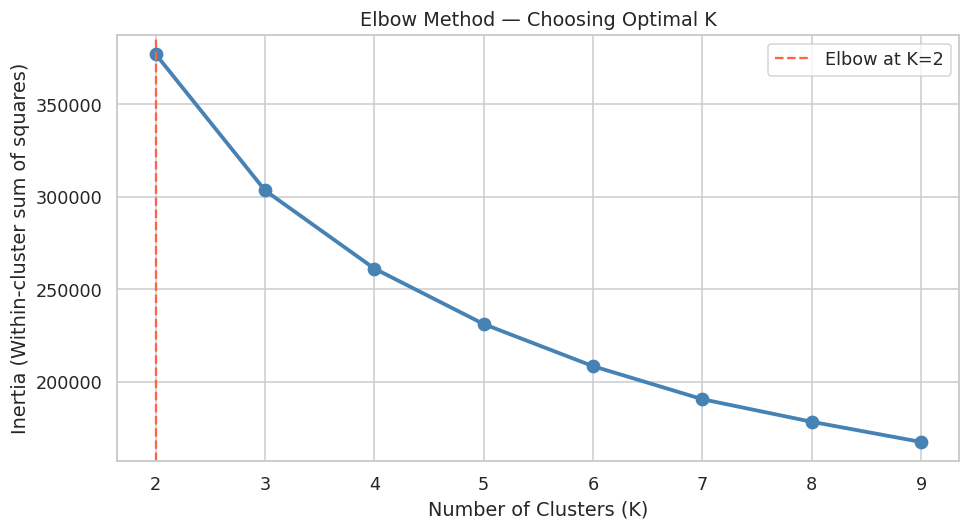

Suggested K from elbow: 2


In [27]:
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, marker='o', linewidth=2.5, color='steelblue', markersize=8)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster sum of squares)')
ax.set_title('Elbow Method — Choosing Optimal K')

# Mark elbow
diffs  = np.diff(inertias)
diffs2 = np.diff(diffs)
elbow  = np.argmax(diffs2) + 2  # +2 because of double diff offset
ax.axvline(elbow, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Elbow at K={elbow}')
ax.legend()
plt.tight_layout(); plt.show()
print(f"Suggested K from elbow: {elbow}")


### A.3 Fit K-Means & Profile Clusters

In [28]:
K = 4  # adjust based on elbow plot

km = KMeans(n_clusters=K, random_state=42, n_init=20)
df_clust['cluster'] = km.fit_predict(X_clust)

# Cluster profiles (original scale)
centers_orig = scaler.inverse_transform(km.cluster_centers_)
centers_df   = pd.DataFrame(centers_orig, columns=CLUSTER_LABELS)
centers_df.index = [f'Cluster {i}' for i in range(K)]
centers_df['Size'] = df_clust['cluster'].value_counts().sort_index().values
centers_df['Size %'] = (centers_df['Size'] / len(df_clust) * 100).round(1)

print("Cluster Centers (original scale):")
print(centers_df.round(2).to_string())


Cluster Centers (original scale):
           Depression (PHQ-9)  Anxiety (GAD-7)  Loneliness  Flourishing   Size  Size %
Cluster 0               12.40            10.03        3.87        49.81  63470    37.4
Cluster 1               20.55            19.66        5.43        45.20  33467    19.7
Cluster 2               16.26            12.51        6.66        39.92  43647    25.7
Cluster 3               26.76            22.06        7.87        32.44  29218    17.2


### A.4 Cluster Radar Chart

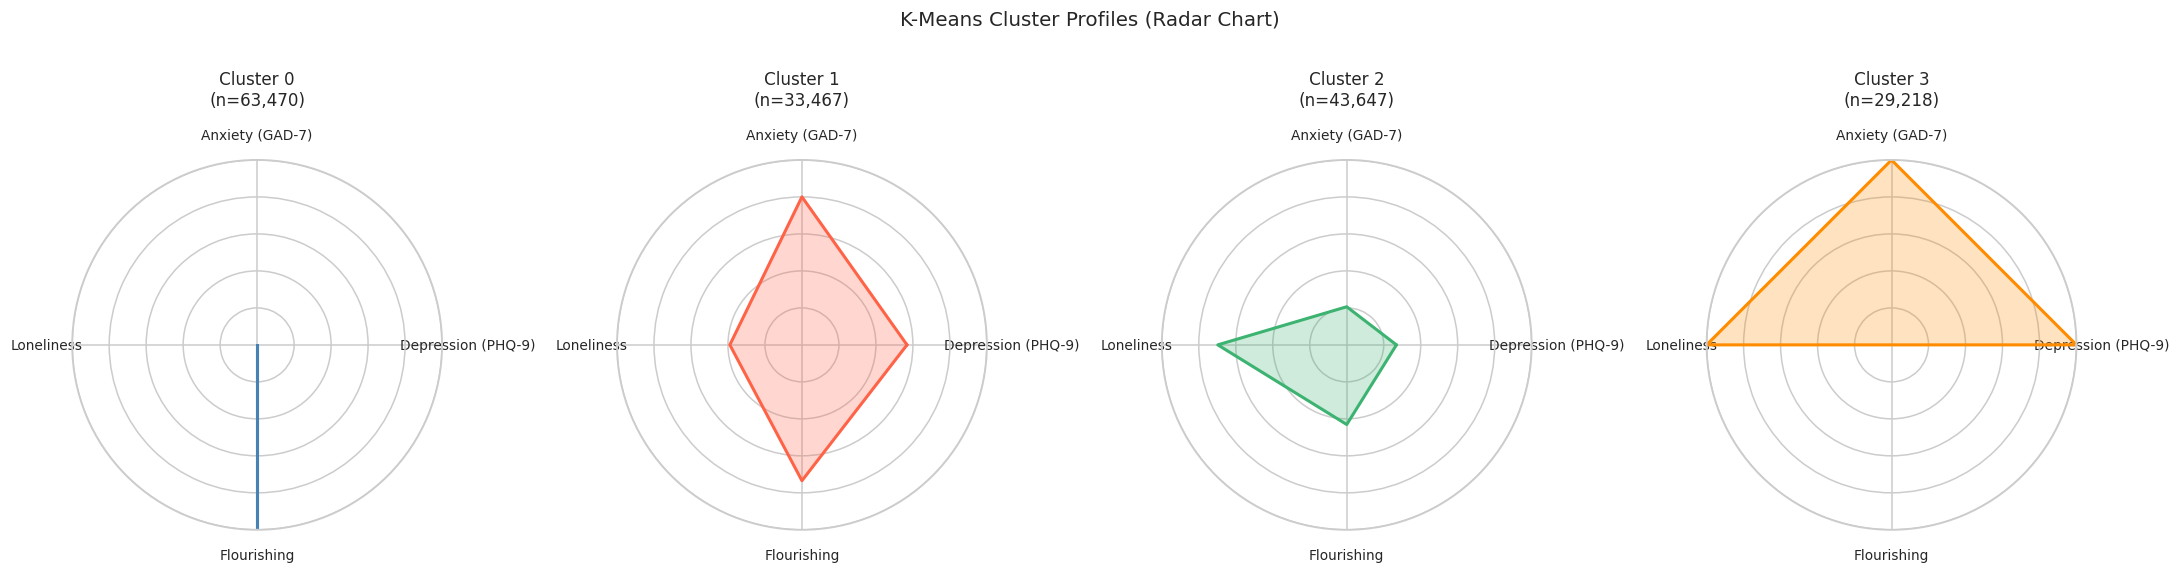

In [29]:
# Normalise centers to 0-1 for radar
mins = centers_orig.min(axis=0)
maxs = centers_orig.max(axis=0)
centers_norm = (centers_orig - mins) / (maxs - mins + 1e-9)

angles = np.linspace(0, 2*np.pi, len(CLUSTER_LABELS), endpoint=False).tolist()
angles += angles[:1]

colors_cl = ['steelblue','tomato','mediumseagreen','darkorange']

fig, axes = plt.subplots(1, K, figsize=(5*K, 5), subplot_kw=dict(polar=True))
for i, ax in enumerate(axes):
    vals = centers_norm[i].tolist() + [centers_norm[i][0]]
    ax.plot(angles, vals, color=colors_cl[i], linewidth=2)
    ax.fill(angles, vals, color=colors_cl[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(CLUSTER_LABELS, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {i}\n(n={int(centers_df.loc[f"Cluster {i}","Size"]):,})',
                 fontsize=11, pad=15)
    ax.set_yticklabels([])

plt.suptitle('K-Means Cluster Profiles (Radar Chart)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### A.5 Cluster Heatmap & Naming

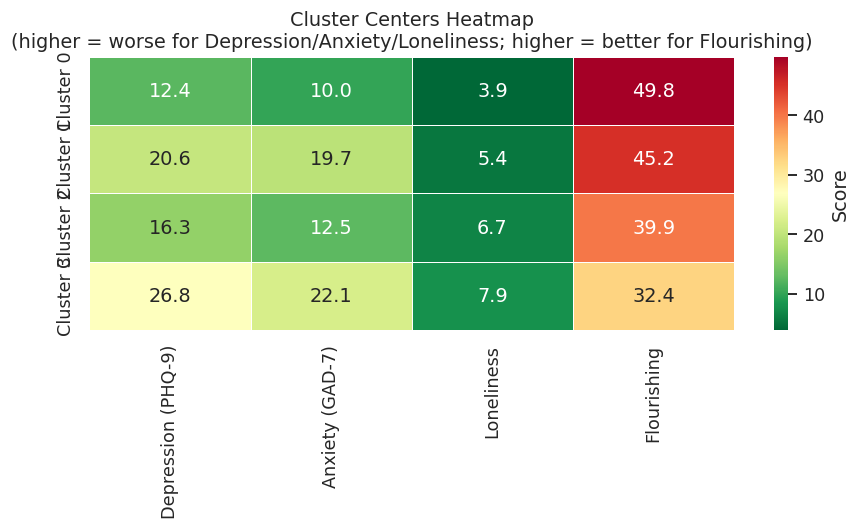


Cluster Interpretation:
(Assign names after reviewing the heatmap and radar charts)
Suggested naming based on typical K=4 results:
  Cluster with low dep/anx + high flourishing  → 'Resilient'
  Cluster with moderate scores                  → 'Moderate Distress'
  Cluster with high dep/anx + high loneliness   → 'High Distress'
  Cluster with very high dep/anx + low flourish → 'Severe Distress'


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(centers_df[CLUSTER_LABELS], annot=True, fmt='.1f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Score'})
ax.set_title('Cluster Centers Heatmap\n(higher = worse for Depression/Anxiety/Loneliness; higher = better for Flourishing)')
ax.set_xlabel('')
plt.tight_layout(); plt.show()

# Name clusters based on profiles
print("\nCluster Interpretation:")
print("(Assign names after reviewing the heatmap and radar charts)")
print("Suggested naming based on typical K=4 results:")
print("  Cluster with low dep/anx + high flourishing  → 'Resilient'")
print("  Cluster with moderate scores                  → 'Moderate Distress'")
print("  Cluster with high dep/anx + high loneliness   → 'High Distress'")
print("  Cluster with very high dep/anx + low flourish → 'Severe Distress'")


### A.6 Clusters in PCA Space

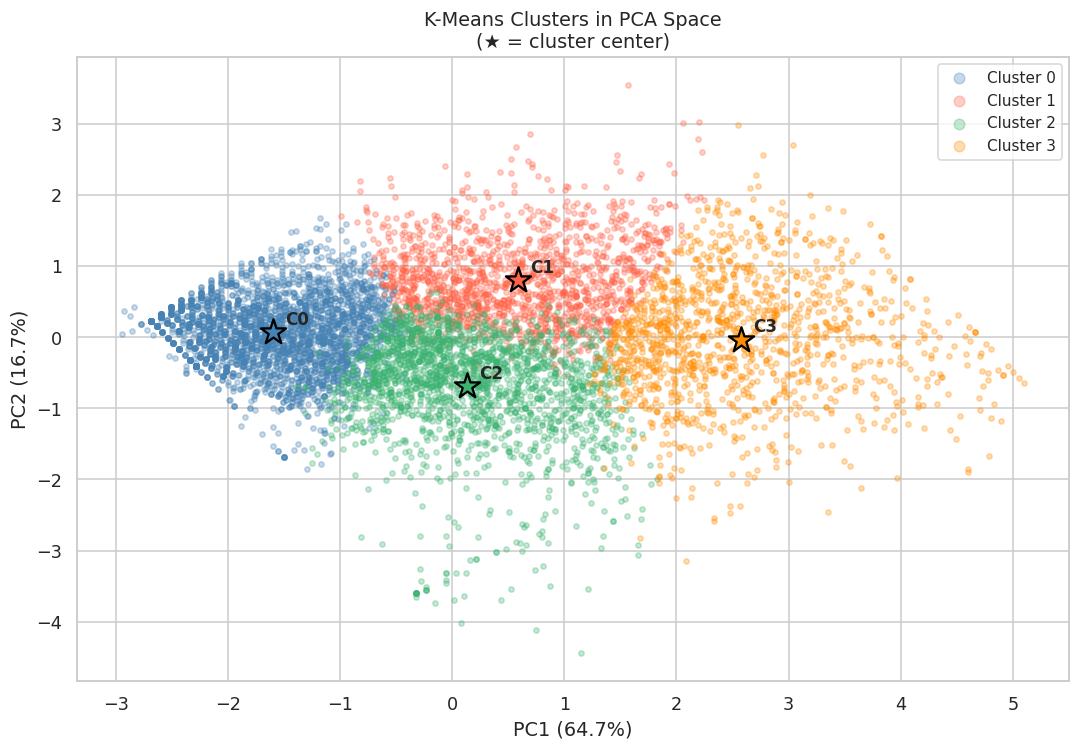

In [31]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_clust)

sample_idx = np.random.RandomState(42).choice(len(X_pca2), size=min(8000, len(X_pca2)), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(K):
    mask = df_clust['cluster'].values[sample_idx] == i
    ax.scatter(X_pca2[sample_idx[mask], 0], X_pca2[sample_idx[mask], 1],
               alpha=0.3, s=12, color=colors_cl[i], label=f'Cluster {i}')

# Plot cluster centers in PCA space
centers_pca = pca2.transform(km.cluster_centers_)
for i in range(K):
    ax.scatter(centers_pca[i, 0], centers_pca[i, 1],
               s=300, color=colors_cl[i], marker='*', edgecolors='black',
               linewidth=1.5, zorder=5)
    ax.annotate(f'C{i}', (centers_pca[i, 0], centers_pca[i, 1]),
                textcoords='offset points', xytext=(8, 5),
                fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters in PCA Space\n(★ = cluster center)')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout(); plt.show()


---
## Part B: Classification — Predicting Suicidal Ideation

**Target:** `sui_idea` — whether a student reported suicidal ideation in the past year (binary: 0/1)

**Features:** Clinical scores, financial stress, behaviors, demographics, institution context

**Models:** Logistic Regression (interpretable baseline) vs Random Forest (non-linear)


### B.1 Prepare Classification Data

In [32]:
FEATURES = {
    'gad7_total':       'Anxiety (GAD-7)',
    'loneliness':       'Loneliness',
    'flourishing':      'Flourishing',
    'low_income':       'Low Income',
    'housing_insecure': 'Housing Insecurity',
    'food_worry':       'Food Insecurity',
    'sib_any':          'Self-Injury',
    'ther_any':         'In Therapy',
    'meds_any':         'On Medication',
    'inst_public':      'Public Institution',
    'inst_size':        'Institution Size',
    'yr_sch':           'Year in School',
    'is_woman':         'Woman',
    'is_nonbinary':     'Non-binary',
}
TARGET = 'sui_idea'

feat_cols = list(FEATURES.keys())
ml_df = df[feat_cols + [TARGET]].dropna()

X = ml_df[feat_cols].values
y = ml_df[TARGET].values.astype(int)

print(f"ML dataset: {len(ml_df):,} rows")
print(f"Features:   {len(feat_cols)}")
print(f"Positive (suicidal ideation): {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"Negative:                     {(1-y).sum():,} ({(1-y).mean()*100:.1f}%)")


ML dataset: 152,283 rows
Features:   14
Positive (suicidal ideation): 18,157 (11.9%)
Negative:                     134,126 (88.1%)


### B.2 Train/Test Split & Class Balancing

The dataset has **12% positive** (suicidal ideation). We compare three balancing strategies:
- **Original** — keep as-is, use `class_weight='balanced'`
- **Undersample** — randomly reduce majority class to 1:1 ratio
- **Undersample 3:1** — reduce majority to 3× minority (less aggressive)

In [33]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Test set: {len(X_test):,} samples  ({y_test.mean()*100:.1f}% positive)")
print()

# ── Strategy 1: Original (imbalanced, class_weight handles it) ────────────
X_train_orig = X_train_full
y_train_orig = y_train_full

# ── Strategy 2: Undersample 1:1 ──────────────────────────────────────────
rng = np.random.RandomState(42)
pos_idx = np.where(y_train_full == 1)[0]
neg_idx = np.where(y_train_full == 0)[0]
neg_sampled_1to1 = rng.choice(neg_idx, size=len(pos_idx), replace=False)
idx_1to1 = np.concatenate([pos_idx, neg_sampled_1to1])
rng.shuffle(idx_1to1)
X_train_1to1 = X_train_full[idx_1to1]
y_train_1to1 = y_train_full[idx_1to1]

# ── Strategy 3: Undersample 3:1 ──────────────────────────────────────────
neg_sampled_3to1 = rng.choice(neg_idx, size=len(pos_idx)*3, replace=False)
idx_3to1 = np.concatenate([pos_idx, neg_sampled_3to1])
rng.shuffle(idx_3to1)
X_train_3to1 = X_train_full[idx_3to1]
y_train_3to1 = y_train_full[idx_3to1]

strategies = [
    ('Original (class_weight)',  X_train_orig,  y_train_orig),
    ('Undersample 1:1',          X_train_1to1,  y_train_1to1),
    ('Undersample 3:1',          X_train_3to1,  y_train_3to1),
]

print(f"{'Strategy':<30} {'Train size':>12} {'Positive %':>12}")
print("-" * 56)
for name, Xtr, ytr in strategies:
    print(f"{name:<30} {len(Xtr):>12,} {ytr.mean()*100:>11.1f}%")

# Use 1:1 as default for subsequent cells (best balance)
X_train = X_train_1to1
y_train = y_train_1to1
print(f"\nUsing: Undersample 1:1 for model training")


Test set: 30,457 samples  (11.9% positive)

Strategy                         Train size   Positive %
--------------------------------------------------------
Original (class_weight)             121,826        11.9%
Undersample 1:1                      29,052        50.0%
Undersample 3:1                      58,104        25.0%

Using: Undersample 1:1 for model training


### B.3 Train Models

In [34]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000,
                                   random_state=42, C=1.0))
])
lr_pipe.fit(X_train, y_train)
print("Logistic Regression trained.")

# ── Random Forest ─────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)
print("Random Forest trained.")


Logistic Regression trained.
Random Forest trained.


### B.3b Strategy Comparison — Which Balancing Works Best?

               Strategy               Model    AUC     F1  Recall  Precision  Accuracy
Original (class_weight) Logistic Regression 0.8475 0.4389  0.7711     0.3068    0.7650
Original (class_weight)       Random Forest 0.8483 0.2446  0.1506     0.6504    0.8891
        Undersample 1:1 Logistic Regression 0.8475 0.4384  0.7725     0.3061    0.7641
        Undersample 1:1       Random Forest 0.8479 0.4300  0.7995     0.2941    0.7473
        Undersample 3:1 Logistic Regression 0.8475 0.4384  0.7703     0.3064    0.7647
        Undersample 3:1       Random Forest 0.8482 0.4612  0.4597     0.4628    0.8720


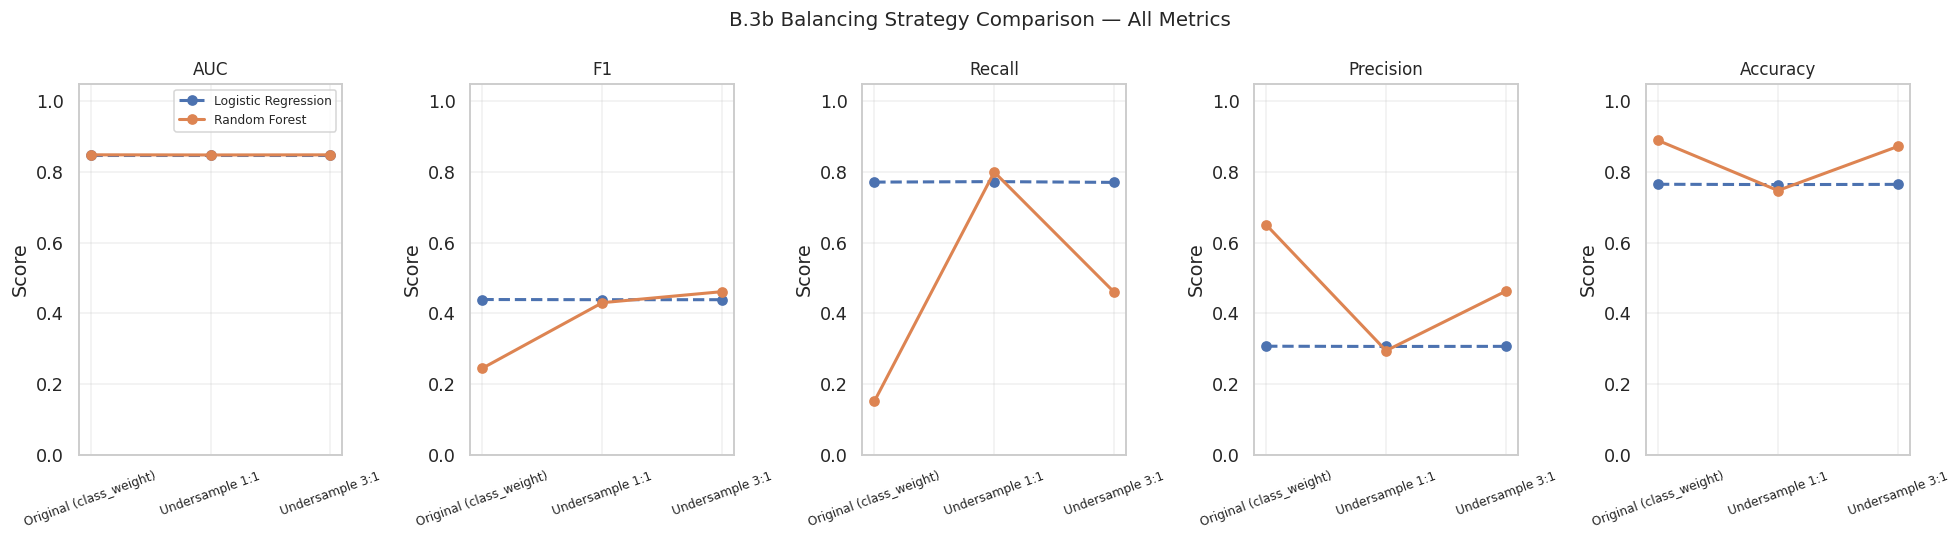


Best strategy per metric:
  AUC       : Original (class_weight) + Random Forest (0.8483)
  F1        : Undersample 3:1 + Random Forest (0.4612)
  Recall    : Undersample 1:1 + Random Forest (0.7995)
  Precision : Original (class_weight) + Random Forest (0.6504)
  Accuracy  : Original (class_weight) + Random Forest (0.8891)


In [35]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

results_compare = []

for strat_name, Xtr, ytr in strategies:
    # Logistic Regression
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, C=1.0))
    ])
    pipe.fit(Xtr, ytr)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    results_compare.append({
        'Strategy': strat_name,
        'Model': 'Logistic Regression',
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred, pos_label=1), 4),
        'Recall':    round(recall_score(y_test, y_pred, pos_label=1), 4),
        'Precision': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Accuracy':  round((y_pred == y_test).mean(), 4),
    })

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 min_samples_leaf=50, random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    y_prob = rf.predict_proba(X_test)[:, 1]
    y_pred = rf.predict(X_test)
    results_compare.append({
        'Strategy': strat_name,
        'Model': 'Random Forest',
        'AUC':       round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred, pos_label=1), 4),
        'Recall':    round(recall_score(y_test, y_pred, pos_label=1), 4),
        'Precision': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Accuracy':  round((y_pred == y_test).mean(), 4),
    })

comp_df = pd.DataFrame(results_compare)
print(comp_df.to_string(index=False))

# ── Visual comparison ─────────────────────────────────────────────────────
metrics_show = ['AUC','F1','Recall','Precision','Accuracy']
fig, axes = plt.subplots(1, len(metrics_show), figsize=(18, 5))

colors_strat = ['steelblue','tomato','mediumseagreen']
markers = ['o','s','D']

for ax, metric in zip(axes, metrics_show):
    for model_name, ls in [('Logistic Regression','--'), ('Random Forest','-')]:
        sub = comp_df[comp_df['Model']==model_name]
        ax.plot(sub['Strategy'], sub[metric], marker='o', lw=2,
                linestyle=ls, label=model_name)
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    if metric == 'AUC':
        ax.legend(fontsize=8)

plt.suptitle('B.3b Balancing Strategy Comparison — All Metrics', fontsize=13)
plt.tight_layout(); plt.show()

print("\nBest strategy per metric:")
for metric in metrics_show:
    best_row = comp_df.loc[comp_df[metric].idxmax()]
    print(f"  {metric:10s}: {best_row['Strategy']} + {best_row['Model']} ({best_row[metric]:.4f})")


### B.4 Evaluation — Classification Reports

In [36]:
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)
    print(f"{'='*55}")
    print(f"{name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Ideation','Suicidal Ideation']))
    print(f"ROC-AUC:           {auc:.4f}")
    print(f"Avg Precision:     {ap:.4f}")
    print()


Logistic Regression
                   precision    recall  f1-score   support

      No Ideation       0.96      0.76      0.85     26826
Suicidal Ideation       0.31      0.77      0.44      3631

         accuracy                           0.76     30457
        macro avg       0.63      0.77      0.64     30457
     weighted avg       0.88      0.76      0.80     30457

ROC-AUC:           0.8475
Avg Precision:     0.4529

Random Forest
                   precision    recall  f1-score   support

      No Ideation       0.96      0.74      0.84     26826
Suicidal Ideation       0.29      0.80      0.43      3631

         accuracy                           0.75     30457
        macro avg       0.63      0.77      0.63     30457
     weighted avg       0.88      0.75      0.79     30457

ROC-AUC:           0.8479
Avg Precision:     0.4504



### B.5 Confusion Matrices

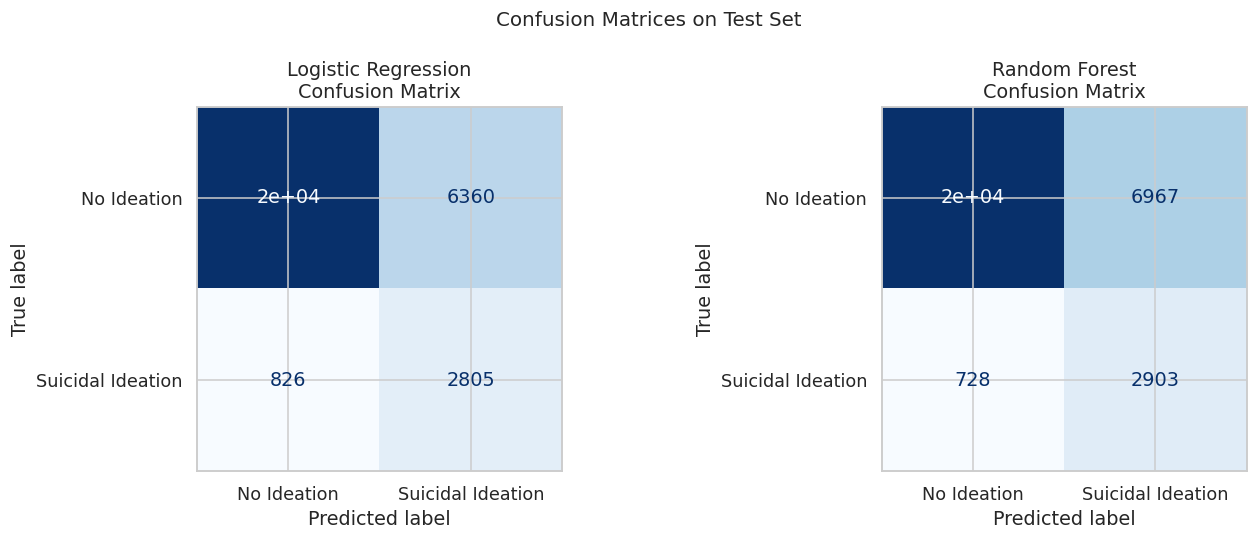

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [('Logistic Regression', lr_pipe),
                                      ('Random Forest', rf_clf)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Ideation','Suicidal Ideation'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix')

plt.suptitle('Confusion Matrices on Test Set', fontsize=13)
plt.tight_layout(); plt.show()


### B.6 ROC Curves

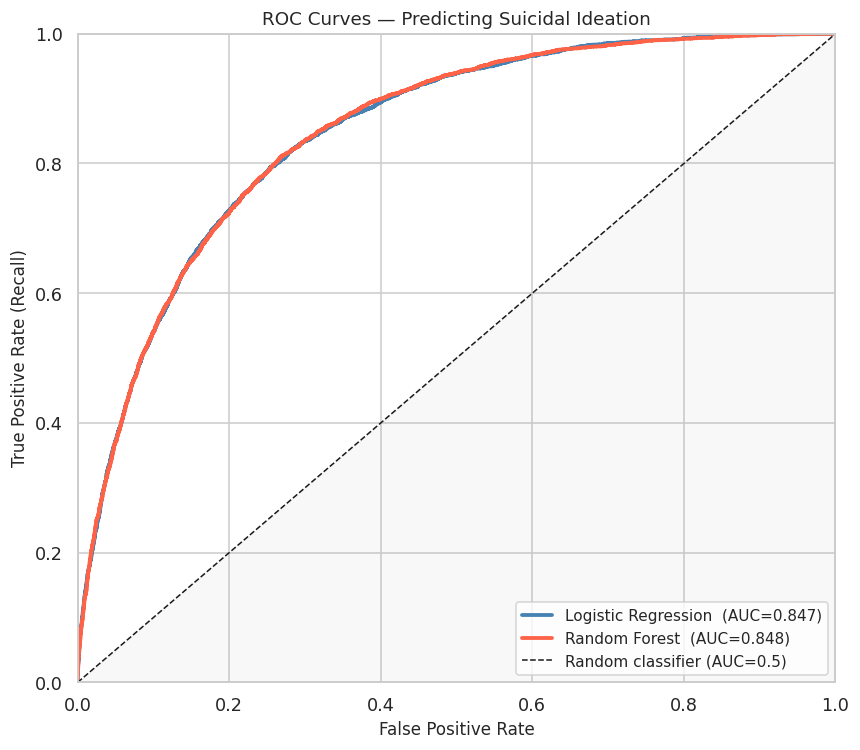

In [38]:
fig, ax = plt.subplots(figsize=(8, 7))

colors_roc = ['steelblue', 'tomato']
for (name, model), color in zip([('Logistic Regression', lr_pipe),
                                   ('Random Forest', rf_clf)], colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Predicting Suicidal Ideation', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()


### B.7 Precision-Recall Curves

More informative than ROC for imbalanced targets (12% positive).

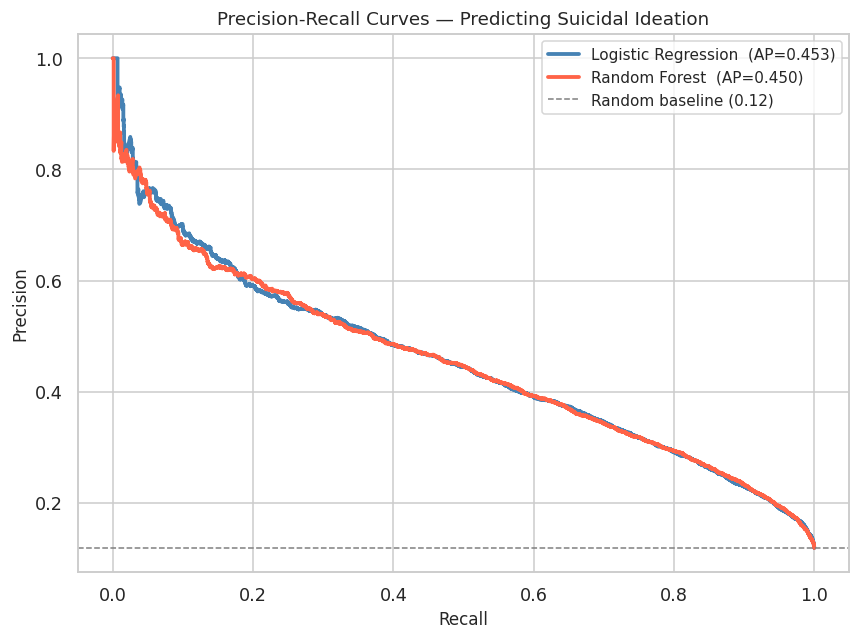

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip([('Logistic Regression', lr_pipe),
                                   ('Random Forest', rf_clf)], colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, linewidth=2.5, label=f'{name}  (AP={ap:.3f})')

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — Predicting Suicidal Ideation', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


### B.8 Feature Importance

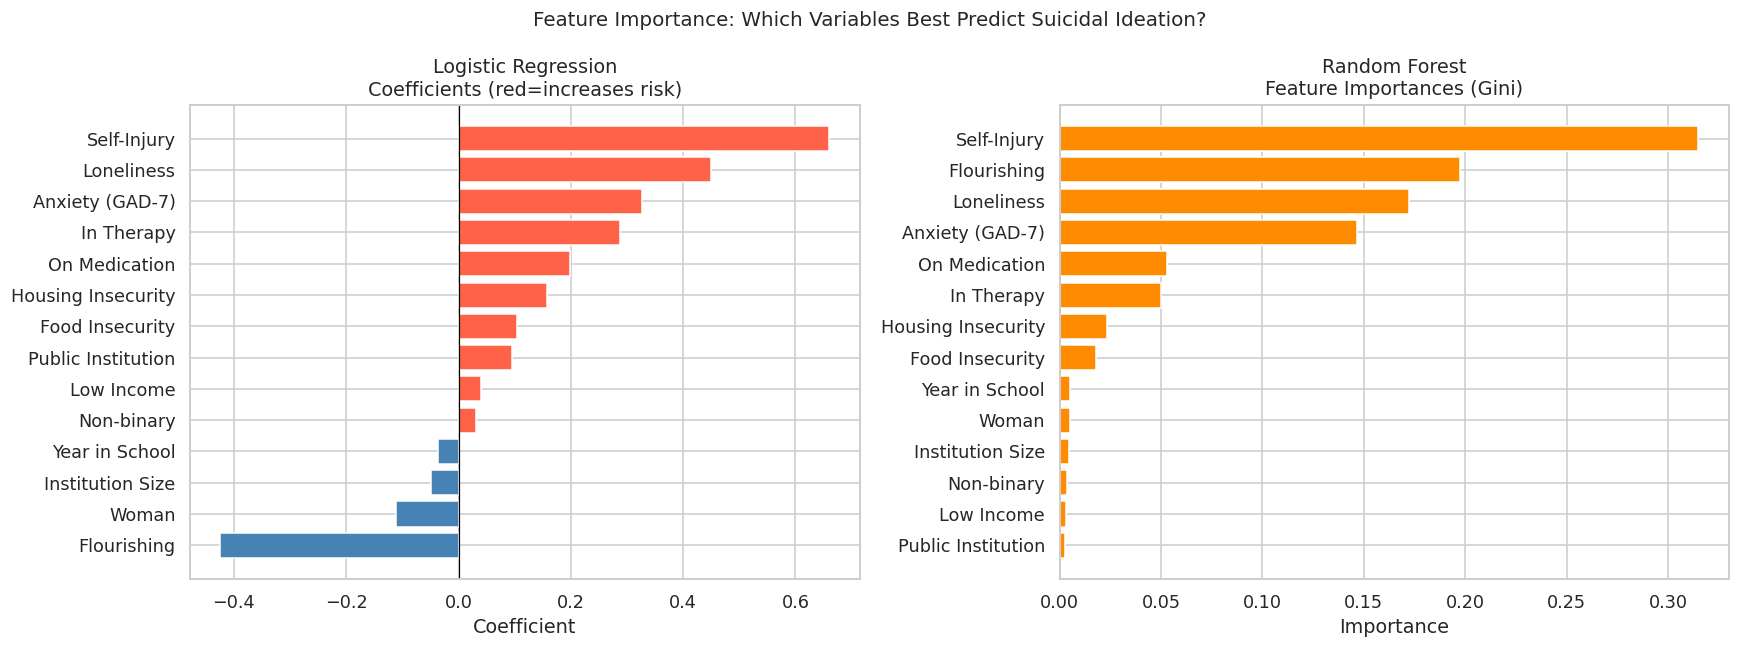

In [40]:
feat_names = list(FEATURES.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression — coefficients
lr_coefs = lr_pipe.named_steps['clf'].coef_[0]
coef_df  = pd.DataFrame({'feature': feat_names, 'coef': lr_coefs})
coef_df  = coef_df.sort_values('coef')
colors_lr = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coef']]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression\nCoefficients (red=increases risk)')
axes[0].set_xlabel('Coefficient')

# Random Forest — feature importances
rf_imp = pd.DataFrame({'feature': feat_names,
                        'importance': rf_clf.feature_importances_})
rf_imp = rf_imp.sort_values('importance')
axes[1].barh(rf_imp['feature'], rf_imp['importance'],
             color='darkorange', edgecolor='white')
axes[1].set_title('Random Forest\nFeature Importances (Gini)')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance: Which Variables Best Predict Suicidal Ideation?',
             fontsize=13)
plt.tight_layout(); plt.show()


### B.9 Cross-Validation Summary

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation (ROC-AUC):")
print("-" * 40)
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    print(f"{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Fold scores: {[round(s,4) for s in scores]}")


5-Fold Cross-Validation (ROC-AUC):
----------------------------------------
Logistic Regression      : 0.8484 ± 0.0061
  Fold scores: [np.float64(0.8386), np.float64(0.844), np.float64(0.8516), np.float64(0.8534), np.float64(0.8542)]
Random Forest            : 0.8488 ± 0.0055
  Fold scores: [np.float64(0.841), np.float64(0.8441), np.float64(0.8505), np.float64(0.8528), np.float64(0.8558)]


### B.10 Threshold Analysis — Precision vs Recall Tradeoff

In mental health screening, missing an at-risk student (false negative) is more costly than a false alarm. This plot shows how precision and recall change as we move the decision threshold.

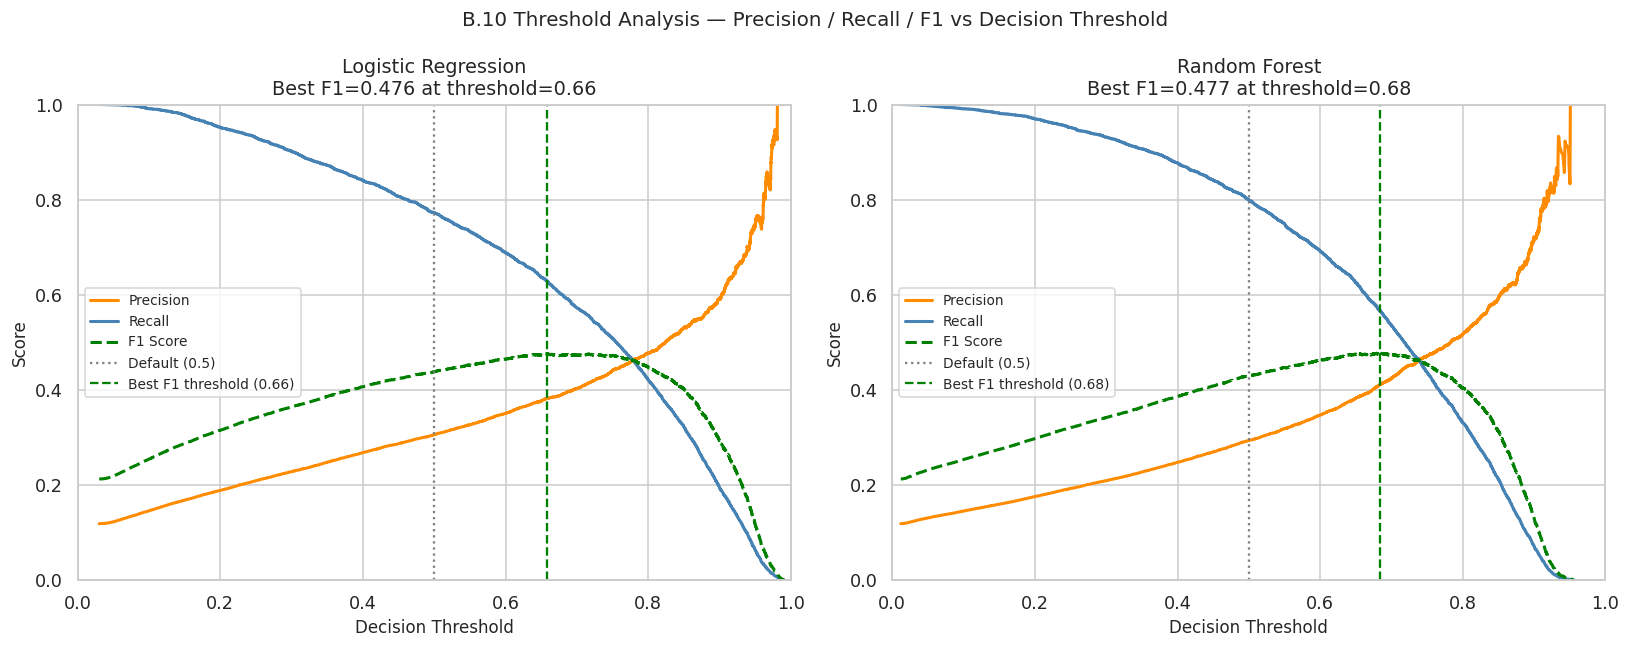

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model), color in zip(axes,
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)],
    ['steelblue', 'tomato']):

    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)

    ax.plot(thresholds, prec[:-1], color='darkorange', lw=2, label='Precision')
    ax.plot(thresholds, rec[:-1],  color='steelblue',  lw=2, label='Recall')

    # F1 score at each threshold
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    ax.plot(thresholds, f1, color='green', lw=2, linestyle='--', label='F1 Score')

    # Mark default threshold (0.5)
    ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default (0.5)')

    # Mark best F1 threshold
    best_t = thresholds[np.argmax(f1)]
    best_f1 = np.max(f1)
    ax.axvline(best_t, color='green', linestyle='--', lw=1.5,
               label=f'Best F1 threshold ({best_t:.2f})')

    ax.set_xlabel('Decision Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{name}\nBest F1={best_f1:.3f} at threshold={best_t:.2f}')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('B.10 Threshold Analysis — Precision / Recall / F1 vs Decision Threshold',
             fontsize=13)
plt.tight_layout(); plt.show()


### B.11 Predicted Probability Distributions

How well does each model separate the two classes? Good separation = two distinct peaks.

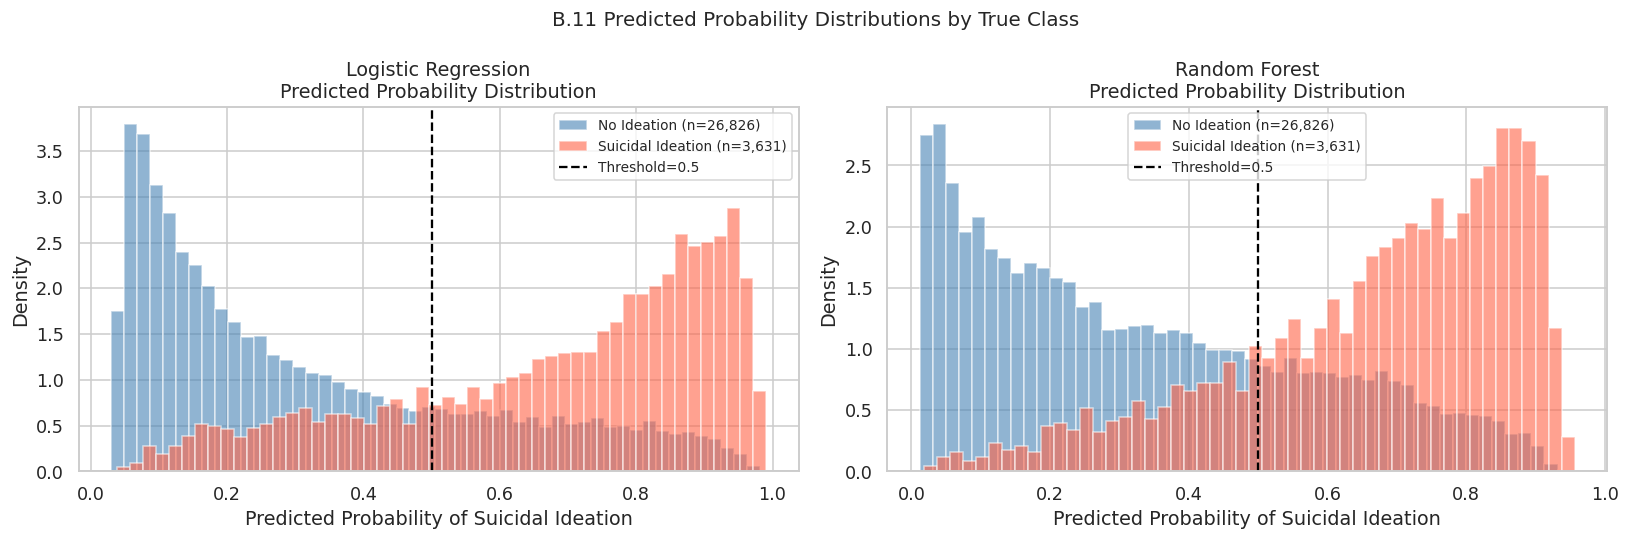

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (name, model) in zip(axes,
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]):

    y_prob = model.predict_proba(X_test)[:, 1]

    # Separate probabilities by true class
    prob_neg = y_prob[y_test == 0]
    prob_pos = y_prob[y_test == 1]

    ax.hist(prob_neg, bins=50, alpha=0.6, color='steelblue',
            label=f'No Ideation (n={len(prob_neg):,})', density=True)
    ax.hist(prob_pos, bins=50, alpha=0.6, color='tomato',
            label=f'Suicidal Ideation (n={len(prob_pos):,})', density=True)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
    ax.set_xlabel('Predicted Probability of Suicidal Ideation')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nPredicted Probability Distribution')
    ax.legend(fontsize=9)

plt.suptitle('B.11 Predicted Probability Distributions by True Class', fontsize=13)
plt.tight_layout(); plt.show()


### B.12 Calibration Curves

A well-calibrated model means: when it says 70% probability, 70% of those students actually have suicidal ideation. The diagonal = perfect calibration.

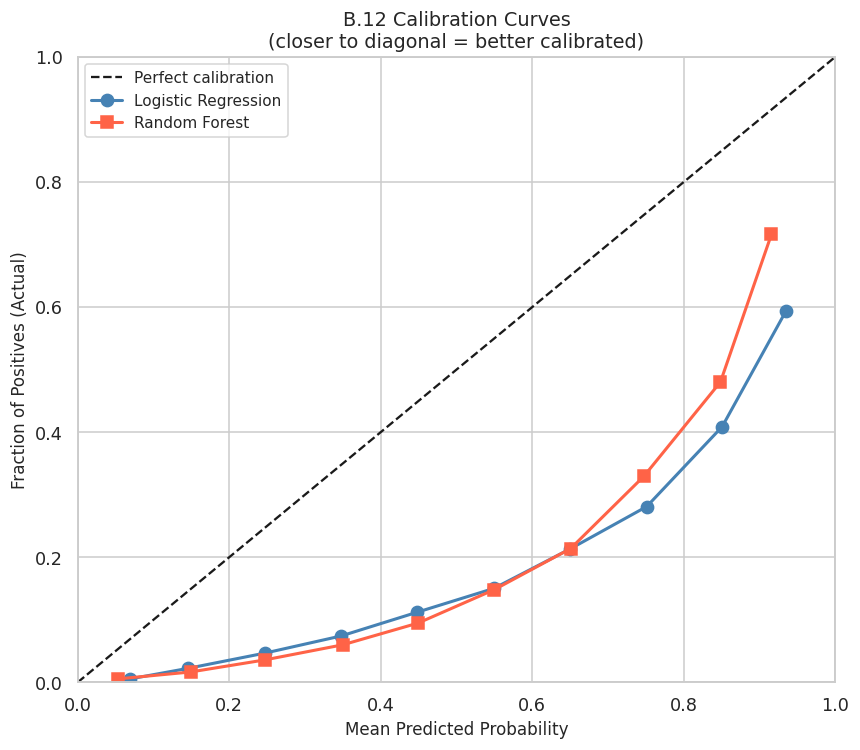

In [44]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')

for (name, model), color, marker in zip(
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)],
    ['steelblue','tomato'], ['o','s']):

    y_prob = model.predict_proba(X_test)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker=marker, color=color,
            lw=2, markersize=8, label=name)

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=11)
ax.set_title('B.12 Calibration Curves\n(closer to diagonal = better calibrated)')
ax.legend(fontsize=10)
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()


### B.13 Feature Importance — Sorted Comparison

Side-by-side ranking of features by importance for both models.

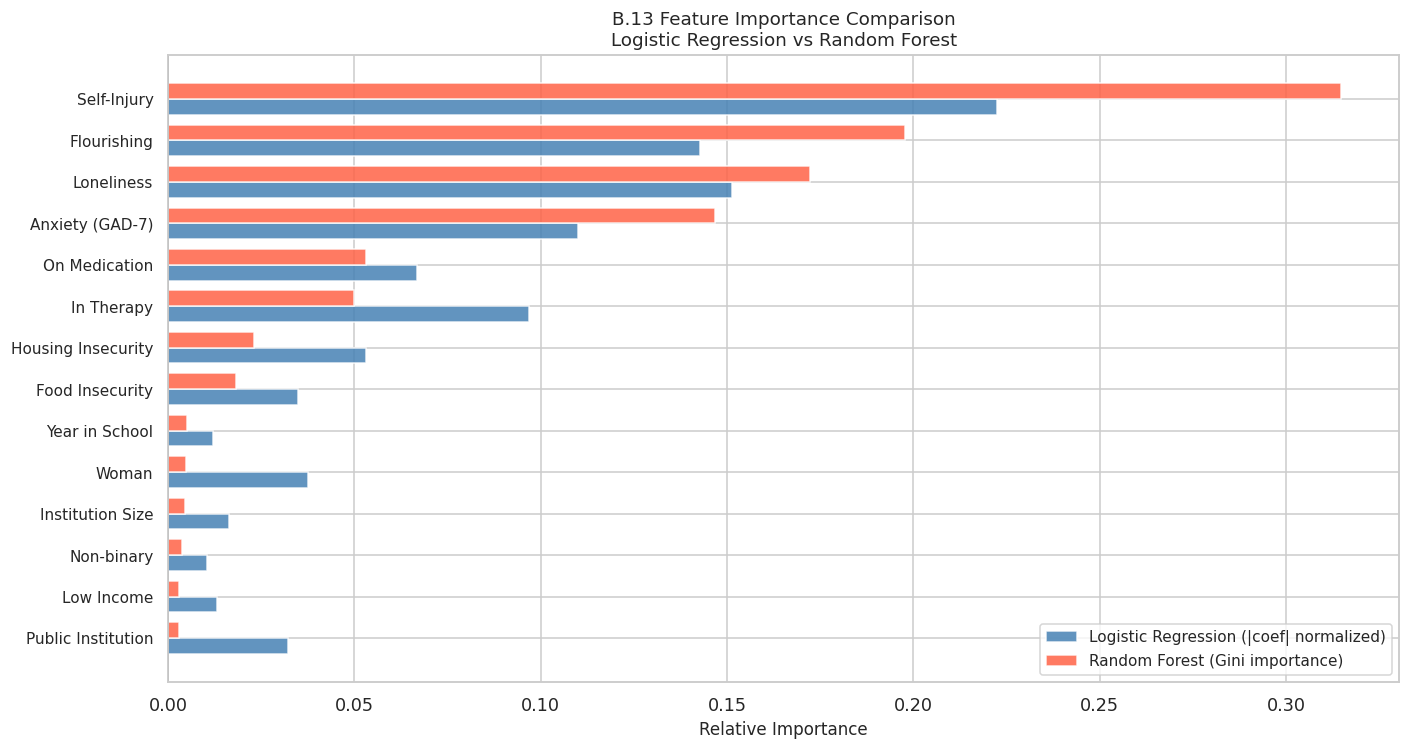

In [45]:
feat_names = list(FEATURES.values())

# LR absolute coefficients (standardized)
lr_coefs = np.abs(lr_pipe.named_steps['clf'].coef_[0])
rf_imps  = rf_clf.feature_importances_

# Sort by RF importance
sort_idx = np.argsort(rf_imps)
sorted_names = [feat_names[i] for i in sort_idx]
sorted_lr    = lr_coefs[sort_idx]
sorted_rf    = rf_imps[sort_idx]

x = np.arange(len(feat_names))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 7))
bars1 = ax.barh(x - w/2, sorted_lr / sorted_lr.sum(), w,
                label='Logistic Regression (|coef| normalized)',
                color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.barh(x + w/2, sorted_rf, w,
                label='Random Forest (Gini importance)',
                color='tomato', alpha=0.85, edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(sorted_names, fontsize=10)
ax.set_xlabel('Relative Importance', fontsize=11)
ax.set_title('B.13 Feature Importance Comparison\nLogistic Regression vs Random Forest',
             fontsize=12)
ax.legend(fontsize=10)
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()


### B.14 Learning Curves

Do the models improve with more training data, or have they already plateaued?

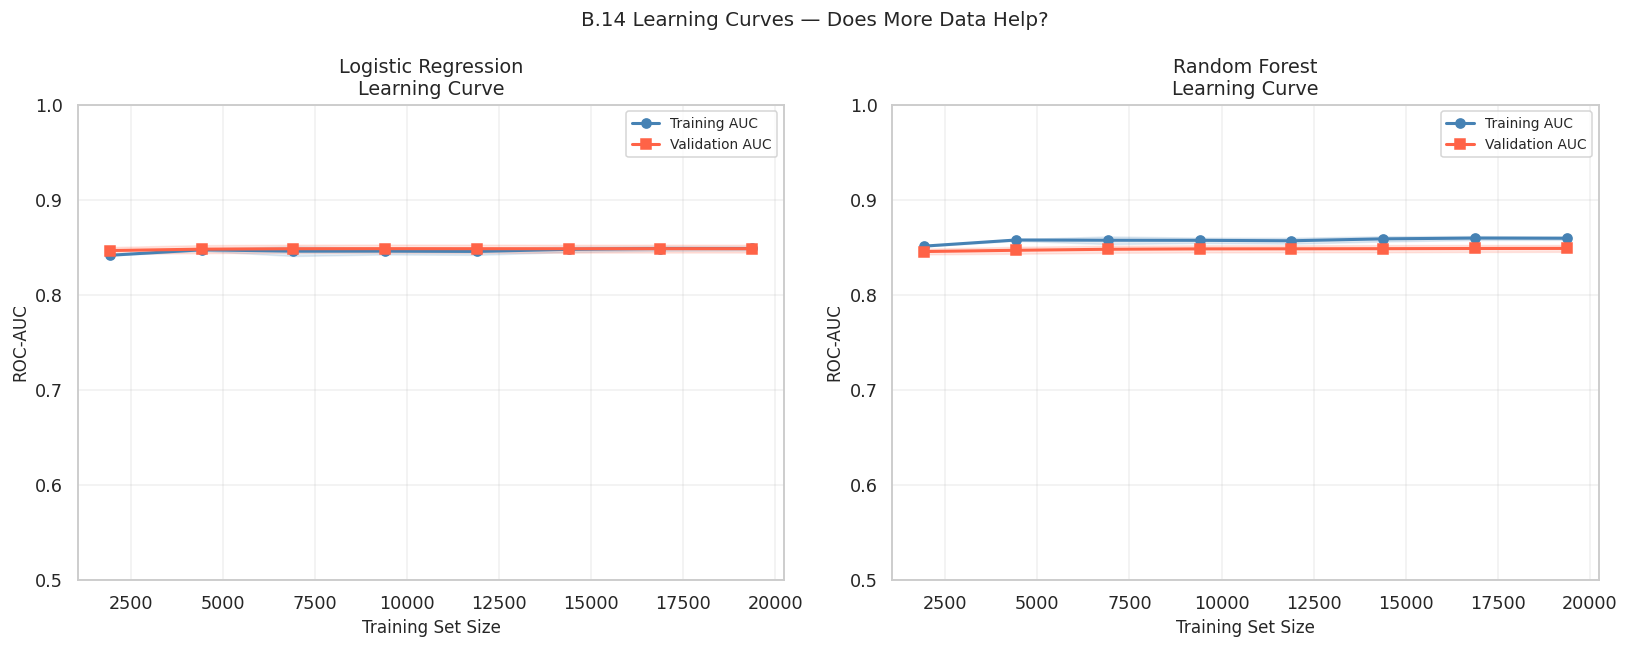

In [46]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model) in zip(axes,
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]):

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=3, scoring='roc_auc',
        n_jobs=-1, random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', lw=2, label='Training AUC')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 's-', color='tomato', lw=2, label='Validation AUC')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color='tomato')

    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('ROC-AUC', fontsize=11)
    ax.set_title(f'{name}\nLearning Curve')
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.grid(alpha=0.3)

plt.suptitle('B.14 Learning Curves — Does More Data Help?', fontsize=13)
plt.tight_layout(); plt.show()


### B.15 Model Comparison Summary Chart

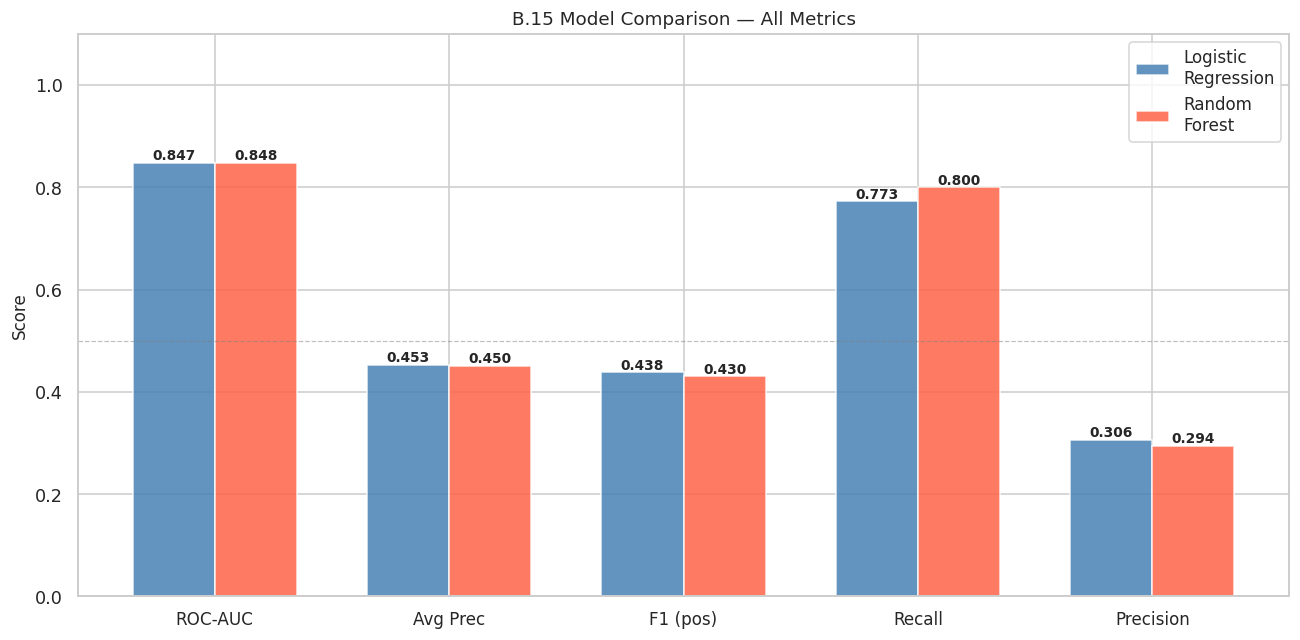

In [47]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_data = []
for name, model in [('Logistic\nRegression', lr_pipe), ('Random\nForest', rf_clf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics_data.append({
        'Model':     name,
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'Avg Prec':  average_precision_score(y_test, y_prob),
        'F1 (pos)':  f1_score(y_test, y_pred, pos_label=1),
        'Recall':    recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
    })

metric_names = ['ROC-AUC','Avg Prec','F1 (pos)','Recall','Precision']
x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
for i, (row, color) in enumerate(zip(metrics_data, ['steelblue','tomato'])):
    vals = [row[m] for m in metric_names]
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=row['Model'],
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.3f}',
                    (bar.get_x()+bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('B.15 Model Comparison — All Metrics', fontsize=12)
ax.legend(fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.5)
plt.tight_layout(); plt.show()


### B.16 Training vs Validation Accuracy Curves

Tracks accuracy on the training set and validation set as the model sees more data. A large gap between the two = overfitting.

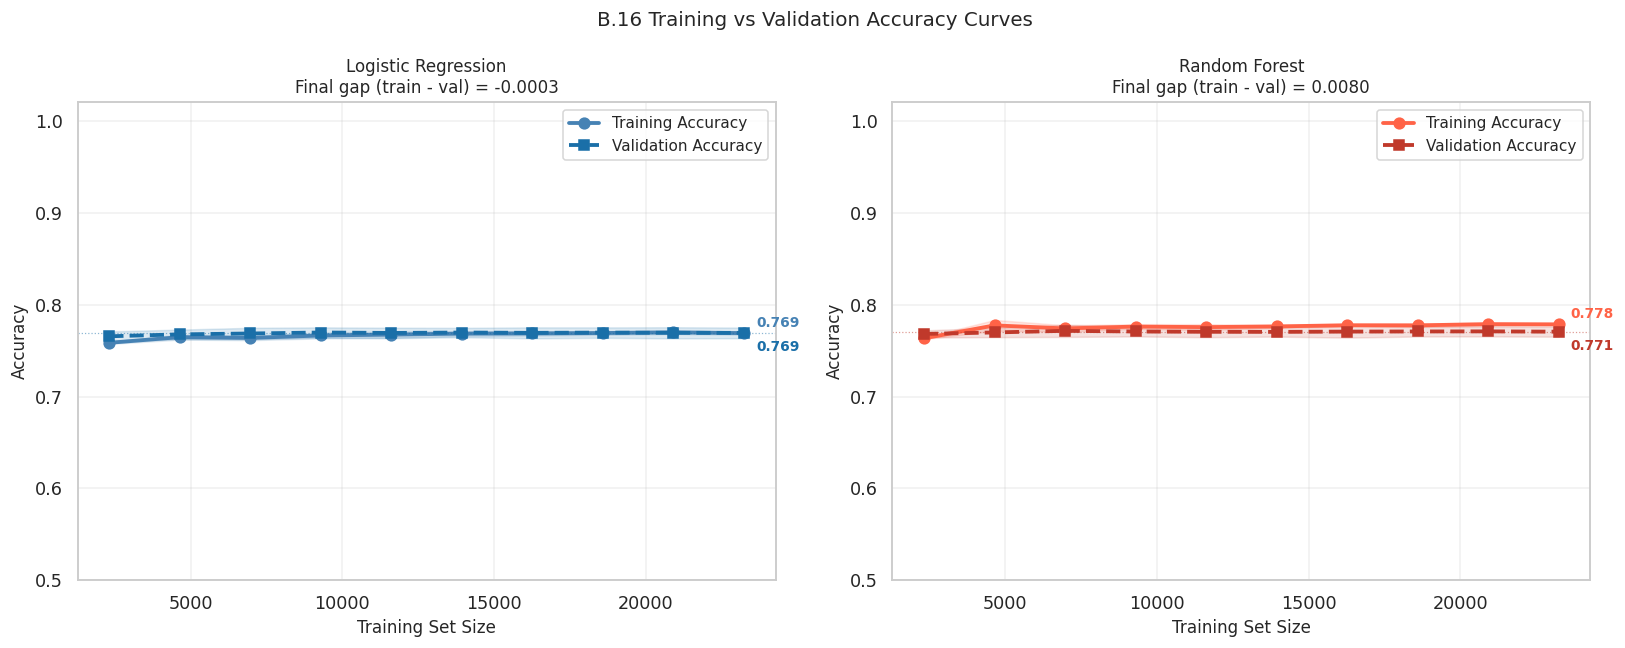

Final accuracy (full training set):
  Logistic Regression      : Train=0.7691  Val=0.7641  Gap=0.0050
  Random Forest            : Train=0.7784  Val=0.7473  Gap=0.0311


In [48]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model), color_train, color_val in zip(
    axes,
    [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)],
    ['steelblue', 'tomato'],
    ['#1a6fa8', '#c0392b']
):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='accuracy',
        n_jobs=-1, random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Training accuracy curve
    ax.plot(train_sizes, train_mean, 'o-', color=color_train, lw=2.5,
            markersize=7, label='Training Accuracy')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=color_train)

    # Validation accuracy curve
    ax.plot(train_sizes, val_mean, 's--', color=color_val, lw=2.5,
            markersize=7, label='Validation Accuracy')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color=color_val)

    # Annotate final values
    ax.annotate(f'{train_mean[-1]:.3f}',
                (train_sizes[-1], train_mean[-1]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=color_train, fontweight='bold')
    ax.annotate(f'{val_mean[-1]:.3f}',
                (train_sizes[-1], val_mean[-1]),
                textcoords='offset points', xytext=(8, -12),
                fontsize=9, color=color_val, fontweight='bold')

    gap = train_mean[-1] - val_mean[-1]
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{name}\nFinal gap (train - val) = {gap:.4f}', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0.5, 1.02)
    ax.grid(alpha=0.3)
    ax.axhline(val_mean[-1], color=color_val, linestyle=':', lw=0.8, alpha=0.5)

plt.suptitle('B.16 Training vs Validation Accuracy Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Print final numbers
print("Final accuracy (full training set):")
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    from sklearn.metrics import accuracy_score
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc   = accuracy_score(y_test,  model.predict(X_test))
    print(f"  {name:25s}: Train={train_acc:.4f}  Val={val_acc:.4f}  Gap={train_acc-val_acc:.4f}")


## Summary

In [49]:
print("MACHINE LEARNING SUMMARY")
print("=" * 60)
print()
print("PART A — CLUSTERING")
print(f"  Method:   K-Means (K=4)")
print(f"  Features: PHQ-9, GAD-7, Loneliness, Flourishing")
print(f"  Students: {len(df_clust):,}")
print(f"  Result:   4 distinct mental health profiles identified")
print()
print("PART B — CLASSIFICATION")
print(f"  Target:   Suicidal Ideation (12% positive)")
print(f"  Features: {len(feat_cols)} variables")
print(f"  Train/Test: 80/20 stratified split")
print()

for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf_clf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    print(f"  {name:25s}: AUC={auc:.4f}  AP={ap:.4f}")

print()
print("Key finding: The most important predictors of suicidal ideation are")
print("clinical scores (anxiety, loneliness, flourishing) rather than")
print("demographic or institutional variables.")


MACHINE LEARNING SUMMARY

PART A — CLUSTERING
  Method:   K-Means (K=4)
  Features: PHQ-9, GAD-7, Loneliness, Flourishing
  Students: 169,802
  Result:   4 distinct mental health profiles identified

PART B — CLASSIFICATION
  Target:   Suicidal Ideation (12% positive)
  Features: 14 variables
  Train/Test: 80/20 stratified split

  Logistic Regression      : AUC=0.8475  AP=0.4529
  Random Forest            : AUC=0.8479  AP=0.4504

Key finding: The most important predictors of suicidal ideation are
clinical scores (anxiety, loneliness, flourishing) rather than
demographic or institutional variables.
